In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Cau 1

### Xu ly cac tuple co gia tri bi thieu

Theo bai giang, co 6 cach chinh:

1. **Bo qua tuple co gia tri bi thieu**: thuong dung khi nhan lop bi thieu; khong hieu qua neu ta van co nhieu thuoc tinh huu ich trong tuple.
2. **Dien gia tri bi thieu thu cong**: chinh xac neu co thong tin, nhung ton thoi gian va kho ap dung cho tap du lieu lon.
3. **Dung hang soan cuc**: thay bang mot gia tri nhu `Unknown`; don gian nhung co the lam thuat toan hieu nham `Unknown` la mot nhom co y nghia.
4. **Dung thuoc do xu huong trung tam cua thuoc tinh**: dung mean voi du lieu doi xung, median voi du lieu lech.
5. **Dung mean/median theo lop**: tinh gia tri dien thay trong nhom co cung nhan lop voi tuple dang xet.
6. **Dung gia tri co xac suat cao nhat**: du doan gia tri thieu dua tren cac thuoc tinh con lai (vi du mo hinh xac suat/phan lop/hoi quy).

Khong co mot phuong phap tot nhat cho moi bo du lieu; lua chon phu thuoc ty le missing, co che missing, kieu thuoc tinh va muc tieu khai pha.

## Cau 2

In [2]:
age = np.array([13,15,16,16,19,20,20,21,22,22,25,25,25,25,30,33,33,35,35,35,35,36,40,45,46,52,70])
age


array([13, 15, 16, 16, 19, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33,
       35, 35, 35, 35, 36, 40, 45, 46, 52, 70])

### (a) Smoothing by bin means, bin depth = 3

In [3]:
bin_depth = 3
bins = age.reshape(-1, bin_depth)
bin_means = bins.mean(axis=1)
smoothed_bins = np.repeat(bin_means[:, None], bin_depth, axis=1)
smoothed_age = smoothed_bins.ravel()

rows = []
for i, (b, m, sb) in enumerate(zip(bins, bin_means, smoothed_bins), start=1):
    rows.append({
        "bin": i,
        "original": b.tolist(),
        "mean": round(float(m), 2),
        "smoothed": np.round(sb, 2).tolist()
    })

pd.DataFrame(rows)


,bin,original,mean,smoothed
0,1,"[13, 15, 16]",14.67,"[14.67, 14.67, 14.67]"
1,2,"[16, 19, 20]",18.33,"[18.33, 18.33, 18.33]"
2,3,"[20, 21, 22]",21.00,"[21.0, 21.0, 21.0]"
3,4,"[22, 25, 25]",24.00,"[24.0, 24.0, 24.0]"
4,5,"[25, 25, 30]",26.67,"[26.67, 26.67, 26.67]"
5,6,"[33, 33, 35]",33.67,"[33.67, 33.67, 33.67]"
6,7,"[35, 35, 35]",35.00,"[35.0, 35.0, 35.0]"
7,8,"[36, 40, 45]",40.33,"[40.33, 40.33, 40.33]"
8,9,"[46, 52, 70]",56.00,"[56.0, 56.0, 56.0]"


In [4]:
print("Du lieu sau khi lam min bang bin means:")
print(np.round(smoothed_age, 2))


Du lieu sau khi lam min bang bin means:
[14.67 14.67 14.67 18.33 18.33 18.33 21.   21.   21.   24.   24.   24.
 26.67 26.67 26.67 33.67 33.67 33.67 35.   35.   35.   40.33 40.33 40.33
 56.   56.   56.  ]


**Nhan xet:** bin means lam giam dao dong cuc bo bang cach thay moi gia tri trong mot bin bang trung binh cua bin do. Tuy nhien, no lam mat chi tiet cua du lieu. Voi bin cuoi `[46, 52, 70]`, gia tri ngoai le `70` keo trung binh cua ca bin len `56`, nen anh huong cua outlier khong bi loai bo ma con duoc truyen sang cac diem lan can.

### (b) Xac dinh outlier

In [5]:
q1, q3 = np.percentile(age, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = age[(age < lower_bound) | (age > upper_bound)]

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Lower bound =", lower_bound)
print("Upper bound =", upper_bound)
print("Outlier(s) =", outliers)


Q1 = 20.5
Q3 = 35.0
IQR = 14.5
Lower bound = -1.25
Upper bound = 56.75
Outlier(s) = [70]


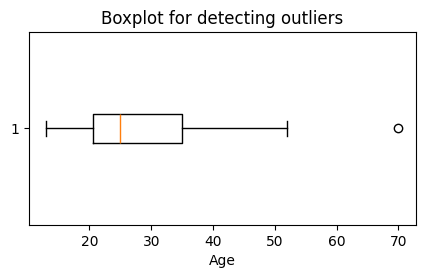

In [6]:
plt.figure(figsize=(5, 2.5))
plt.boxplot(age, vert=False)
plt.xlabel("Age")
plt.title("Boxplot for detecting outliers")
plt.show()


Theo quy tac boxplot/IQR, gia tri nam ngoai $[Q_1-1.5IQR,\;Q_3+1.5IQR]$ duoc xem la outlier. Voi du lieu nay, `70` la outlier. Bai giang cung neu **outlier analysis bang clustering**: cac diem nam xa/ngoai cac cum co the duoc xem la ngoai le.

### (c) Cac phuong phap smoothing khac

Ngoai **smoothing by bin means**, co the dung:

- **Smoothing by bin medians**: thay moi gia tri bang trung vi cua bin.
- **Smoothing by bin boundaries**: thay moi gia tri bang bien gan nhat (min hoac max cua bin).
- **Regression**: khop du lieu vao mot ham va dung gia tri tren ham de lam min.
- **Clustering / outlier analysis**: gom cac diem tuong tu vao cum, nhan dien cac diem nam ngoai cum de xu ly nhieu.

## Cau 3

### Cac van de can xem xet khi tich hop du lieu

1. **Nhan dien thuc the (entity identification)**: xac dinh cac truong/ban ghi o nhieu nguon co dang noi ve cung mot thuc the hay khong; xu ly khac biet ten thuoc tinh, kieu du lieu va schema.
2. **Du thua va tuong quan (redundancy/correlation)**: cung mot thong tin co the xuat hien o nhieu thuoc tinh/nguon; can phat hien thuoc tinh du thua va quan he giua chung.
3. **Ban ghi trung lap (duplicate tuples)**: mot doi tuong co the xuat hien nhieu lan sau khi merge/join; can phat hien va gop/xoa trung lap.
4. **Xung dot gia tri (data value conflicts)**: cung mot thuc the nhung gia tri khac nhau do don vi, thang do, cach ma hoa, dinh dang hoac thoi diem cap nhat khac nhau.

Muc tieu la giam du thua va khong nhat quan, qua do cai thien do chinh xac va toc do cua qua trinh khai pha.

## Cau 4

In [7]:
ranges = pd.DataFrame({
    "method": [
        "Min-max normalization",
        "Z-score normalization",
        "Z-score using mean absolute deviation",
        "Decimal scaling"
    ],
    "value_range": [
        "[new_min, new_max] (thuong la [0, 1])",
        "(-inf, +inf); thuong phan lon nam trong [-3, 3] neu gan phan phoi chuan",
        "(-inf, +inf)",
        "(-1, 1)"
    ]
})
ranges


,method,value_range
0,Min-max normalization,"[new_min, new_max] (thuong la [0, 1])"
1,Z-score normalization,"(-inf, +inf); thuong phan lon nam trong [-3, 3..."
2,Z-score using mean absolute deviation,"(-inf, +inf)"
3,Decimal scaling,"(-1, 1)"


Ghi chu:

- Min-max anh xa truc tiep vao khoang dich da chon.
- Z-score khong co can duoi/can tren co dinh. Sau chuan hoa bang standard deviation, mean bang 0 va standard deviation bang 1.
- Neu thay standard deviation bang **mean absolute deviation**, ket qua van khong bi gioi han boi mot khoang co dinh.
- Decimal scaling chon so nguyen nho nhat $j$ sao cho $\max(|x'_i|)<1$, vi vay gia tri sau chuan hoa nam trong $(-1,1)$.

## Cau 5

In [8]:
age = np.array([13,15,16,16,19,20,20,21,22,22,25,25,25,25,30,33,33,35,35,35,35,36,40,45,46,52,70], dtype=float)
x = 35.0

mean_age = age.mean()
min_age = age.min()
max_age = age.max()
std_given = 12.94

print("mean(age) =", mean_age)
print("min(age) =", min_age, "max(age) =", max_age)


mean(age) = 29.962962962962962
min(age) = 13.0 max(age) = 70.0


### (a) Min-max normalization ve [0, 1]

In [9]:
x_minmax = (x - min_age) / (max_age - min_age)
print("x' =", x_minmax)


x' = 0.38596491228070173


### (b) Z-score normalization

In [10]:
x_zscore = (x - mean_age) / std_given
print("x' =", x_zscore)


x' = 0.38926097658709724


### (c) Decimal scaling

In [11]:
max_abs = np.max(np.abs(age))
j = int(np.floor(np.log10(max_abs))) + 1
x_decimal = x / (10 ** j)

print("j =", j)
print("x' =", x_decimal)


j = 2
x' = 0.35


### (d) Lua chon phuong phap

Voi bo du lieu nay, **z-score normalization** la lua chon hop ly hon neu muc tieu la chuan hoa de dua vao thuat toan khai pha/hoc may:

- Min-max phu thuoc truc tiep vao `min` va `max`; gia tri `70` la outlier nen keo gian khoang chuan hoa.
- Decimal scaling don gian nhung chi dua vao bac lon nhat cua du lieu, khong phan anh vi tri va do phan tan cua phan phoi.
- Z-score su dung mean va standard deviation nen giu thong tin ve vi tri tuong doi cua diem du lieu theo don vi do lech chuan.

Luu y: z-score van co the bi anh huong boi outlier vi mean va standard deviation cung nhay voi ngoai le; neu can robust hon, co the can nhac cac cach dung median/MAD.

## Cau 6

### Tu dong tao concept hierarchy cho du lieu nominal dua tren so gia tri phan biet

Y tuong: trong mot nhom thuoc tinh co quan he phan cap, thuoc tinh **cang cu the** thuong co **nhieu gia tri phan biet** hon, con thuoc tinh **cang tong quat** thuong co **it gia tri phan biet** hon.

Vi vay:

- Dem `nunique` cho moi thuoc tinh nominal.
- Sap xep giam dan theo so gia tri phan biet de co thu tu **chi tiet -> tong quat**.
- Neu hai thuoc tinh co cung cardinality, chi dua vao so gia tri phan biet thi khong du de xac dinh thu tu; ta dat chung mot muc hoac can them thong tin schema/domain.

In [12]:
def generate_concept_hierarchy(df, attributes):
    # Dem so gia tri phan biet cua moi thuoc tinh
    distinct_counts = {attr: df[attr].nunique(dropna=True) for attr in attributes}

    # Nhom cac thuoc tinh co cung so gia tri phan biet
    levels = {}
    for attr, count in distinct_counts.items():
        levels.setdefault(count, []).append(attr)

    # Nhieu distinct value hon -> cap chi tiet hon (lower level)
    hierarchy = [
        {"distinct_values": count, "attributes": sorted(levels[count])}
        for count in sorted(levels, reverse=True)
    ]
    return distinct_counts, hierarchy


In [13]:
# Vi du minh hoa: street -> city -> province -> country
example = pd.DataFrame({
    "street":   ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"],
    "city":     ["C1", "C1", "C2", "C2", "C3", "C3", "C4", "C4"],
    "province": ["P1", "P1", "P1", "P1", "P2", "P2", "P2", "P2"],
    "country":  ["VN"] * 8
})

attributes = ["street", "city", "province", "country"]
distinct_counts, hierarchy = generate_concept_hierarchy(example, attributes)

print("Distinct counts:", distinct_counts)
print("Hierarchy (specific -> general):")
for level in hierarchy:
    print(level)


Distinct counts: {'street': 8, 'city': 4, 'province': 2, 'country': 1}
Hierarchy (specific -> general):
{'distinct_values': 8, 'attributes': ['street']}
{'distinct_values': 4, 'attributes': ['city']}
{'distinct_values': 2, 'attributes': ['province']}
{'distinct_values': 1, 'attributes': ['country']}


Pseudo-code tuong duong:

```text
INPUT: nominal attributes A1...Ak
FOR each attribute Ai:
    count[Ai] = number_of_distinct_values(Ai)
GROUP attributes having the same count
SORT groups by count in descending order
RETURN groups as hierarchy from specific level to general level
```

Voi vi du tren, ket qua la:

`street -> city -> province -> country`.

Day la suy luan dua tren cardinality. Neu schema thuc te khong co quan he ngu nghia nhu vay, can them metadata/domain knowledge de xac nhan hierarchy.